# CA removal of data chirped corrected in Optimus 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import math
from tkinter.filedialog import askopenfilename, askopenfilenames
from lmfit.models import GaussianModel
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import lmfit
from scipy.stats import norm
from scipy.interpolate import interp1d
%matplotlib widget

# allow multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

def poly2(x, a, b, c):
    return a * x**2 + b * x + c


def poly4(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def gaussian_fwhm(sigma):
    fwhm = 2 * math.sqrt(2 * math.log(2)) * sigma
    return fwhm


def heatmap_interactive(_x, _y, _data, _title, _cmap='jet', _symlog=False):
    # Create a figure with specified size
    fig = plt.figure(figsize=(8, 8))

    # Define a grid layout for the subplots
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.5], height_ratios=[0.5, 1], hspace=0.2, wspace=0.2)

    # Create the main plot in the bottom-left corner of the grid
    ax_main = plt.subplot(gs[1, 0])
    main_plot = ax_main.pcolormesh(_x, _y, _data, cmap=_cmap)
    ax_main.set(xlabel='Delay / ps', ylabel='Wavelength / nm')
    # Set mixed log-lin scale with threshold value linthresh if symlog is True
    if _symlog:
        ax_main.set_xscale('symlog', linthresh=0.01)
    # Set axis range to min and max values
    ax_main.set_xlim(_x[0],_x[-1])
    ax_main.set_ylim(_y[0],_y[-1])

    # Create the kinetic plot in the top-left corner of the grid
    ax_kin = plt.subplot(gs[0, 0])
    line_kin, = ax_kin.plot(_x,np.zeros(_x.shape))
    kin_zero_line, = ax_kin.plot([_x[0],_x[-1]],[0,0], color="0.6")
    ax_kin.set_xlim(_x[0],_x[-1])
    if _symlog:
        ax_kin.set_xscale('symlog', linthresh=0.01)

    # Create the spectrum plot in the bottom-right corner of the grid
    ax_spec = plt.subplot(gs[1, 1])
    line_spec, = ax_spec.plot(np.zeros(_y.shape),_y)
    spec_zero_line, = ax_spec.plot([0,0],[_y[0],_y[-1]], color="0.6")
    ax_spec.set_ylim(_y[0],_y[-1])

    # This lower bounds list is necessary because the blocks in the 2D-plot cover a certain range
    def create_lower_bounds(_value_list):
        result = np.empty_like(_value_list)
        # First lower bound is equal to the lowest value in the nm-list
        result[0] = _value_list[0]
        # Example: lower bound for 100 ps is 97.5 ps if the value prior is 95 ps, and 75 ps if the value prior is 50 ps.
        for i in range(1,len(_value_list)):
            result[i] = (_value_list[i]+_value_list[i-1])/2
        return result

    nm_lower_bounds = create_lower_bounds(_y)
    time_lower_bounds = create_lower_bounds(_x)

    def nm_to_index(_nm):
        return np.where(_nm > nm_lower_bounds)[0][-1]

    def time_to_index(_time):
        return np.where(_time > time_lower_bounds)[0][-1]

    def mouse_move(event):
        x = event.xdata
        y = event.ydata
        if x is not None and y is not None:
            if x>=_x[0] and x<=_x[-1] and y>=_y[0] and y<=_y[-1]:

                # Update spectra slice and rescale
                new_spec = _data[:,time_to_index(x)]
                line_spec.set_xdata(new_spec)
                spec_bounds = ax_spec.get_ylim()
                spec_range = new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()-new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()
                ax_spec.set_xlim(new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()-0.1*spec_range,new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()+0.1*spec_range)

                # Update kinetic slice and rescale
                new_kin = _data[nm_to_index(y),:]
                line_kin.set_ydata(new_kin)
                kin_bounds = ax_kin.get_xlim()
                kin_range = new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()-new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()
                ax_kin.set_ylim(new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()-0.1*kin_range,new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()+0.1*kin_range)

                # Redraw figure
                fig.canvas.draw_idle()

    # Connect mouse move event to the figure
    fig.canvas.mpl_connect('motion_notify_event', mouse_move)

    # Find max absolute value of 2D data in the specified zoom mode of the plot
    def get_maxvalue(_xlim, _ylim, _xvals, _yvals, _data_array):
        y_filter = (_yvals>=_ylim[0]) & (_yvals<=_ylim[1])
        x_filter = (_xvals>=_xlim[0]) & (_xvals<=_xlim[1])

        if not np.all(y_filter == False) and not np.all(x_filter == False):
            return np.amax(np.abs(_data_array[y_filter][:,x_filter]))
        else:
            return 0

    def on_xlims_change(event_ax):
        ax_kin.set_xlim(event_ax.get_xlim())

        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    def on_ylims_change(event_ax):
        ax_spec.set_ylim(event_ax.get_ylim())

        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    # Connect axis limits change events to the respective functions
    ax_main.callbacks.connect('xlim_changed', on_xlims_change)
    ax_main.callbacks.connect('ylim_changed', on_ylims_change)

    # Show the plot
    plt.show(block=False)


def lin(x,a,b):
    return a*x+b


def smooth_data_average_window(data, window_size):
    # Calculate rolling mean with specified window size
    windows = data.rolling(spectral= window_size ,center = True, min_periods=1)
    moving_average = windows.mean()
    return moving_average

def calculate_fwhm(spectral_data, time_coords):
    #spectral_data = np.abs(spectral_data)
    peak_value = np.max(spectral_data)
    half_max = peak_value / 2.0
    indices_above_half = np.where(spectral_data >= half_max)[0]
    
    if len(indices_above_half) < 2:
        return np.nan  # Not enough data to calculate FWHM
    
    max_value = np.where(spectral_data == peak_value )[0]
    valid_indices = [max_value[0]] #Create an where where we gonna remove the data that are above the half but that don't correspond to the peak
    current_value = max_value[0]
    for i in  np.where(indices_above_half > max_value)[0]: #Look in the positive increment  
        if indices_above_half[i] == current_value + 1:
            valid_indices.append(indices_above_half[i])
            current_value += 1
        else:
            break
    current_value = max_value[0]
    for i in  reversed(np.where(indices_above_half < max_value)[0]): #Look in the negative increment  
        if indices_above_half[i] == current_value - 1:
            valid_indices.insert(0,indices_above_half[i])
            current_value -= 1
        else:
            break

    # Interpolate to get a more accurate crossing point
    f_left = interp1d(spectral_data[valid_indices[0]-1:valid_indices[0]+1], time_coords[valid_indices[0]-1:valid_indices[0]+1], kind='linear')
    f_right = interp1d(spectral_data[valid_indices[-1]:valid_indices[-1]+2], time_coords[valid_indices[-1]:valid_indices[-1]+2], kind='linear')
    left_half_max_time = f_left(half_max)
    right_half_max_time = f_right(half_max)
    
    # Calculate FWHM as the difference between these two time points
    fwhm = right_half_max_time - left_half_max_time

    return fwhm 

# Calibration

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pixels)')

Text(0, 0.5, 'Wavelength (nm)')

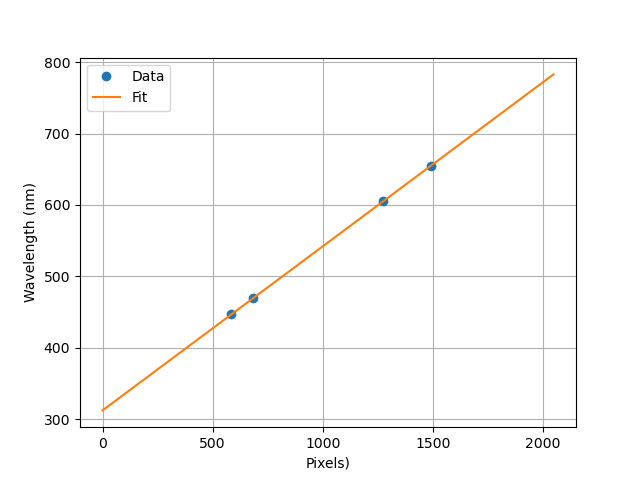

y = 0.22988126536900919x + 312.2796845080387


In [2]:
#Wavelength Calibaration
pixels = np.arange(0, 2048)
#pixels_calibation = [860,1434,1659]
#wv_calibation = [469,605,655]
pixels_calibation = [583,685,1274,1490]
wv_calibation = [447,469,605,655]



calibration,_ = curve_fit(lin,pixels_calibation,wv_calibation, method= "dogbox")
Fit_calibration = lin(pixels,*calibration)

plt.figure()
plt.plot(pixels_calibation,wv_calibation,  'o', label='Data')
plt.plot(pixels,Fit_calibration, '-', label='Fit')
plt.xlabel('Pixels)')
plt.ylabel('Wavelength (nm)')
plt.legend()
plt.grid("On")
plt.show()
print(f"y = {calibration[0]}x + {calibration[1]}")

lambda_values = calibration[0] * pixels + calibration[1]

# Solvent scan

## Import 

<xarray.Dataset> Size: 3MB
Dimensions:   (time: 189, spectral: 2048)
Coordinates:
  * time      (time) float64 2kB -15.0 -5.0 -1.0 -0.9 -0.8 ... 7.0 8.0 9.0 10.0
  * spectral  (spectral) float64 16kB 312.3 312.5 312.7 ... 782.4 782.6 782.8
Data variables:
    data      (time, spectral) float64 3MB 0.001104 0.0006972 ... 0.0006439


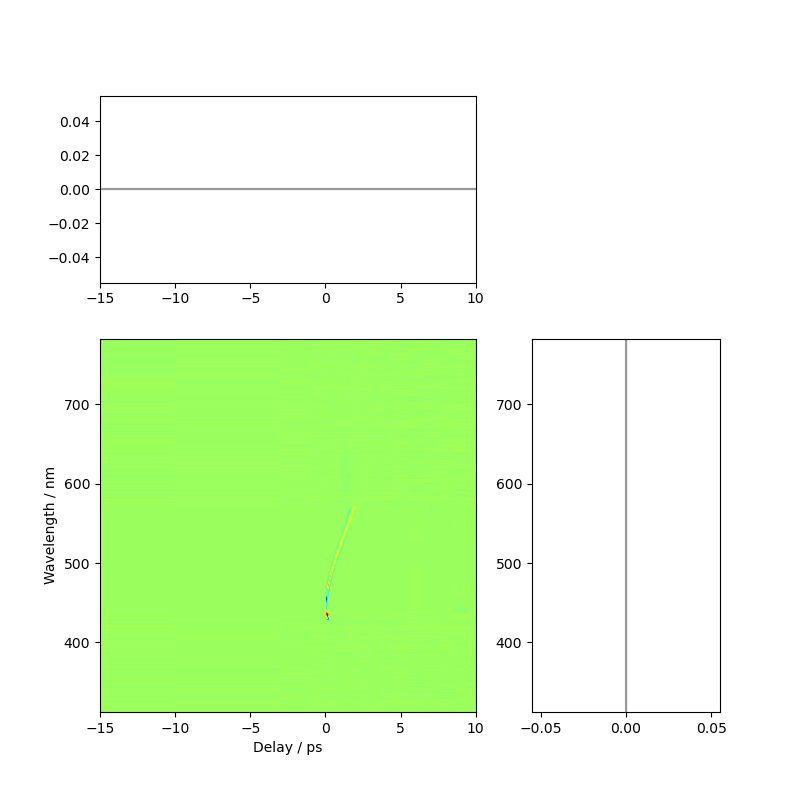

In [3]:
time_file = askopenfilename(filetypes=[("Text files", "*.txt")], title="Select Time vector data")
time_solvent = np.loadtxt(time_file)
time_solvent = time_solvent / 1000  # convert from fs to ps

# Get TA scan files
ta_scan_files = askopenfilenames(filetypes=[("Text files", "*.txt")], title="Select solvent scan file(s)")

if len(ta_scan_files) > 1:
    Full_Data = np.zeros((2048, len(time_solvent), len(ta_scan_files))) #Array that will contain all the 
    for n, file in enumerate(ta_scan_files):
        data = np.loadtxt(file)
        Full_Data[:, :, n] = data  # save data array to 3D array (lambda, time, scan)
    
    scan_solvent = np.mean(Full_Data, axis=2)
    scan_solvent = scan_solvent - np.mean(scan_solvent[:,1:3],axis=1)[:, np.newaxis] #Baseline correction 
else:
    scan_solvent = np.loadtxt(ta_scan_files[0])
# Now 'scan' contains the processed data

#Create an xarray to manipulate the data (much easier)
dataset_solvent = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(scan_solvent))
    },
    coords={
        "time": time_solvent,
        "spectral": lambda_values
    }
)

# Print the dataset
print(dataset_solvent)

heatmap_interactive(dataset_solvent.time, dataset_solvent.spectral, dataset_solvent['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

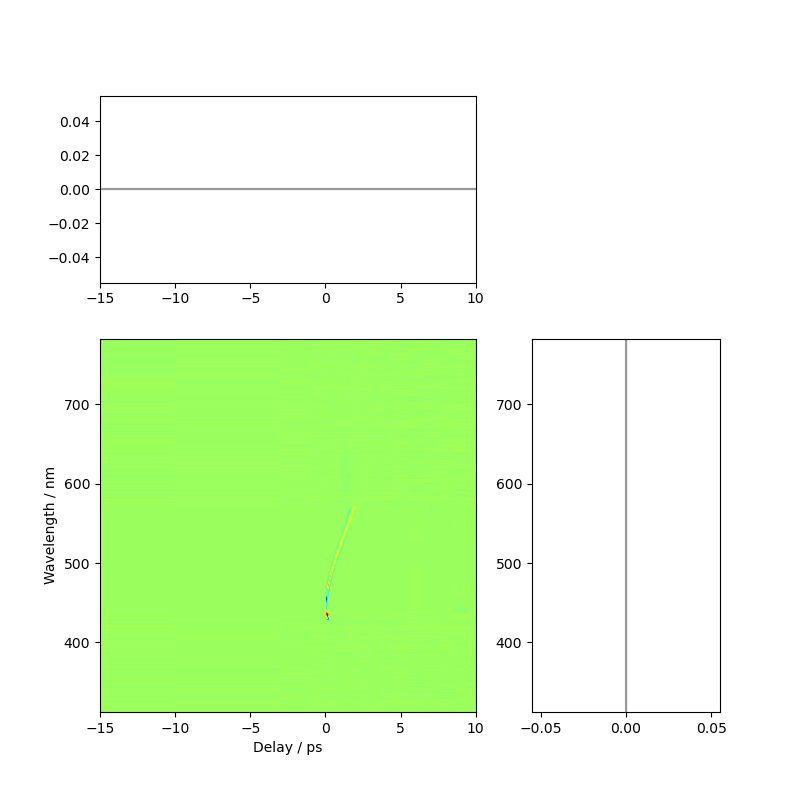

In [4]:
heatmap_interactive(dataset_solvent.time, dataset_solvent.spectral, dataset_solvent['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

## Extract the CA position 

<Figure size 1200x600 with 0 Axes>

(0.0, 400.0)

Text(0.5, 1.0, 'IRF estimation with a Gaussian Fit')

Text(0.5, 0, 'Wavelength (nm)')

Text(0, 0.5, 'FWHM (fs)')

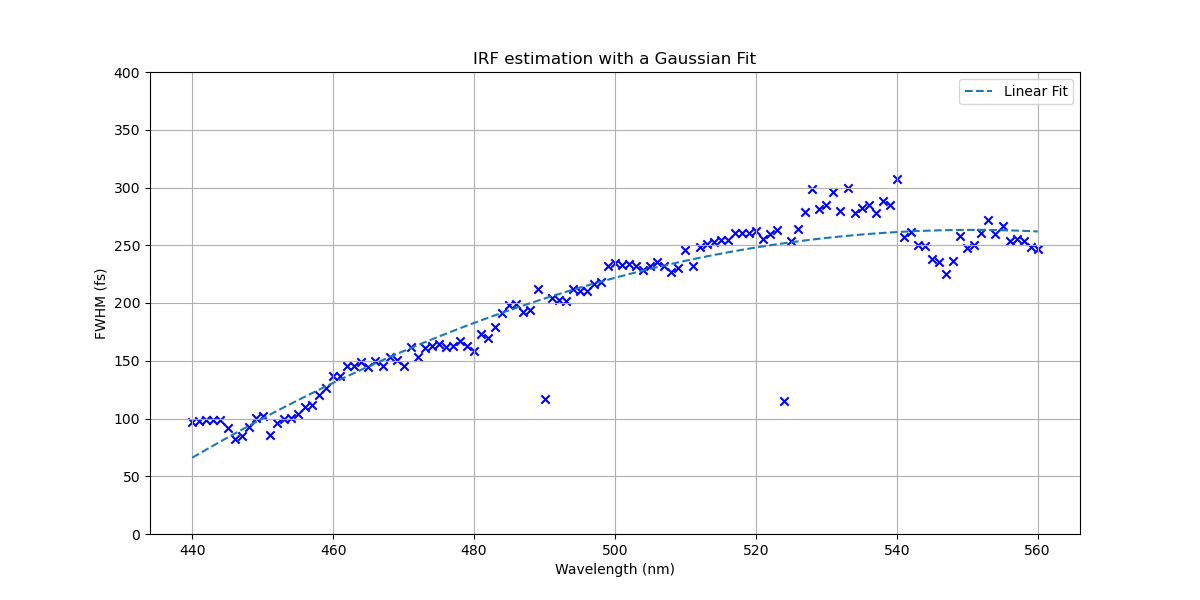

In [6]:
lower_signal_bound = 440
higher_singal_bound = 560
threshold = 0.0035

wl_range = np.arange(lower_signal_bound,higher_singal_bound+1,1)



ROI = smooth_data_average_window(dataset_solvent.sel(spectral=slice(lower_signal_bound, higher_singal_bound)),35)

ROI_FWHM_values = []
gaussian_fit_param = np.zeros([np.shape(wl_range)[0],3])
i = 0


for spectral_value in wl_range: 
    # Extract the kinetic trace for the selected spectral value
    kinetic_trace = np.abs(ROI['data'].sel(spectral=spectral_value, method='nearest'))

    # Find peaks in the kinetic trace
    peaks, _ = find_peaks(kinetic_trace)
    filtered_peaks = peaks[kinetic_trace[peaks] > threshold]

    # Ensure we have at least two peaks
    if len(filtered_peaks) >= 2:
        # Identify the two outermost peaks
        first_peak = filtered_peaks[0]
        last_peak = filtered_peaks[-1]
    # Create a mask where values between the two outermost peaks are removed
        mask = np.ones_like(kinetic_trace, dtype=bool)  
        mask[first_peak:last_peak+1] = False  
        
        # Apply the mask to the data
        sliced_kinetics = kinetic_trace.where(mask) 

        # Fit a Gaussian to the sliced data
        time_data = time_data = np.concatenate([sliced_kinetics.time[0:first_peak].values, sliced_kinetics.time[last_peak+1:].values], axis=0)
        kinetic_data = sliced_kinetics.data[~np.isnan(sliced_kinetics.data)] #Remove the NaN values, needed for the fit 

        # Define Gaussian model
        gauss_model = GaussianModel()

        # Set initial parameters
        gap_center = (sliced_kinetics.time[first_peak].values + sliced_kinetics.time[last_peak].values) / 2
        params = gauss_model.make_params(amplitude=ROI['data'].max().item(), center=gap_center, sigma=np.std(time_data))

        # Fit the model to the data
        fit_result = gauss_model.fit(kinetic_data, params, x=time_data) 

        # Generate smooth fitted curve
        smooth_time = np.linspace(time_data.min(), time_data.max(), 300)
        fitted_curve = gauss_model.eval(fit_result.params, x=smooth_time)

        #Print fitted parameters
        fitted_params = fit_result.params
        gaussian_fit_param[i][0] = fitted_params['amplitude'].value
        gaussian_fit_param[i][1] = fitted_params['center'].value
        gaussian_fit_param[i][2] = fitted_params['sigma'].value
        ROI_FWHM_values.append(gaussian_fwhm(fitted_params['sigma'].value*1000))
        i = i+1
    else:
        fwhm = calculate_fwhm(kinetic_trace, kinetic_trace.time.values)*1000 
        ROI_FWHM_values.append(fwhm)
        i = i+1

# Create a mask for values <= 300
filtered_wl_range = []
filtered_ROI_FWHM_values = []
for wl, fwhm in zip(wl_range, ROI_FWHM_values):
    if fwhm <= 300:
        filtered_wl_range.append(wl)
        filtered_ROI_FWHM_values.append(fwhm)

fwhm_trend_solvent,_ = curve_fit(poly2,filtered_wl_range,filtered_ROI_FWHM_values, method= "dogbox")
fwhm_lin_solvent = poly2(np.array(filtered_wl_range),*fwhm_trend_solvent)
plt.figure(figsize=(12, 6))
plt.scatter(wl_range,ROI_FWHM_values,color='blue', marker='x')
plt.plot(filtered_wl_range,fwhm_lin_solvent, '--', label='Linear Fit') 
plt.legend()
plt.ylim([0,400])
plt.title('IRF estimation with a Gaussian Fit')
plt.grid('On')
plt.xlabel("Wavelength (nm)")
plt.ylabel("FWHM (fs)")



## Fit the solvent CA 

In [7]:
def Fcos(params, time): 
    B = params['B']
    Phi = params['Phi']
    A0 = params['A0']
    A1 = params['A1']
    tau = params['CA_FWHM']
    dt0 = params['CA_center']
    
    cos_term = np.cos(B * (time - dt0)**2 + Phi) 
    exp_term = A0 * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    correction_term = A1 * (8 * np.log(2) / (tau ** 2)) * (time - dt0) * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    
    result = cos_term * (exp_term - correction_term)
    
    return result

def residuals_Fcos(params, time, data):
    model = Fcos(params, time)
    return np.sqrt((model - data)**2)

def Fcos_complex(params, time): 
    B = params['B']
    Phi = params['Phi']
    A0 = params['A0']
    A1 = params['A1']
    tau = params['CA_FWHM']
    dt0 = params['CA_center']
    c = params['c']
    
    cos_term = np.cos(B * (time - dt0)**2 + Phi) 
    exp_term = A0 * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    correction_term = A1 * (8 * np.log(2) / (tau ** 2)) * (time - dt0) * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    
    result = (cos_term * (exp_term - correction_term))/c
    
    return result

def residuals_Fcos_complex(params, time, data):
    model = Fcos_complex(params, time)
    return np.sqrt((model - data)**2)


## Fit the first wavelength

(-0.18000000000000002, 0.32)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(-0.18000000000000002, 0.32)

(-0.05108492342315599, 0.0434323726555064)

Text(0.5, 0.98, 'Modeling Coherent Artifact, solvent scan, 440 nm')

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 350
    # data points      = 42
    # variables        = 6
    chi-square         = 0.00111069
    reduced chi-square = 3.0853e-05
    Akaike info crit   = -430.698460
    Bayesian info crit = -420.272442
[[Variables]]
    B:          220.773098 +/- 226.465687 (102.58%) (init = 200.2462)
    Phi:        157.535497 +/- 1.06913913 (0.68%) (init = 157.5085)
    A0:        -0.00359740 +/- 0.00394762 (109.74%) (init = -0.03)
    A1:         0.00292485 +/- 0.00223362 (76.37%) (init = 0.03)
    CA_FWHM:    0.07961861 +/- 0.00860413 (10.81%) (init = 0.06607969)
    CA_center:  0.05023304 +/- 0.00141836 (2.82%) (init = 0.05)
[[Correlations]] (unreported correlations are < 0.100)
    C(B, Phi)        = -0.9939
    C(Phi, A1)       = +0.9913
    C(B, A1)         = -0.9783
    C(A1, CA_FWHM)   = +0.8237
    C(Phi, CA_FWHM)  = +0.7617
    C(B, CA_FWHM)    = -0.7379
    C(B, A0)         = +0.5573
    C(Phi, A0)       = -0.5

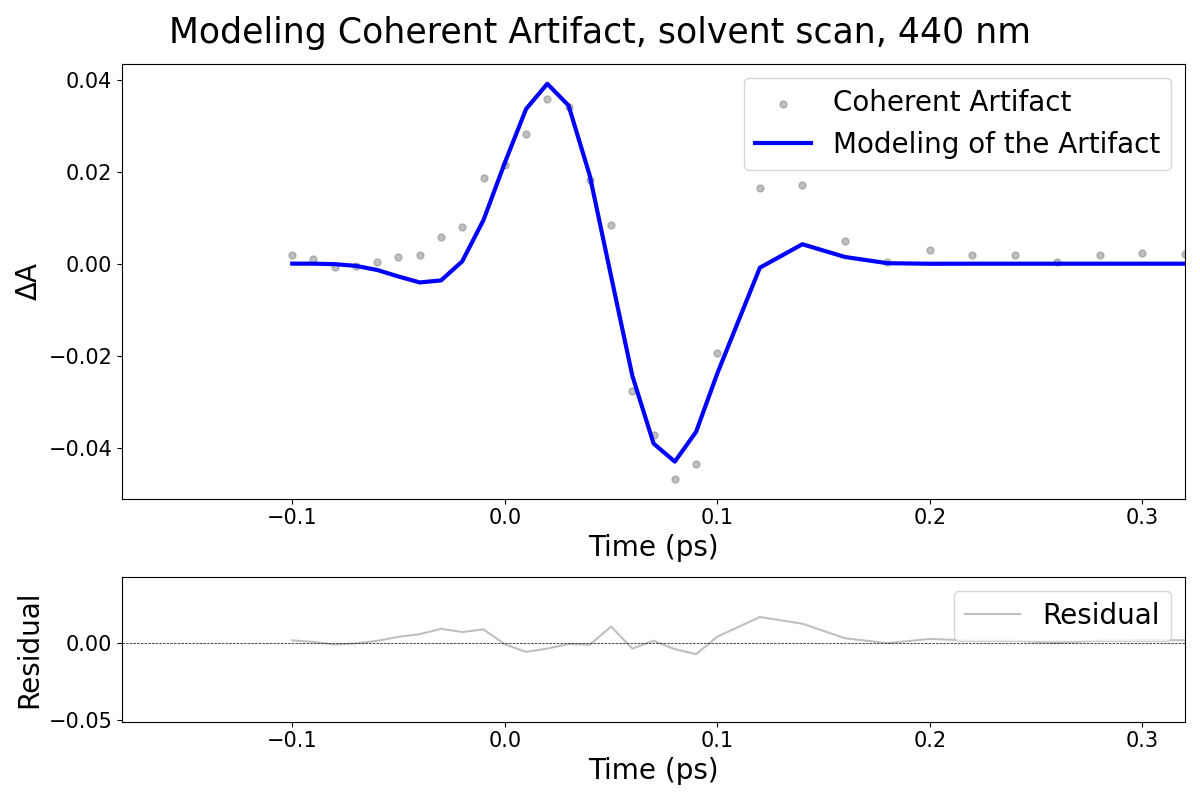

In [15]:
wv_1 = 440 #in nm

xml_region = dataset_solvent.data
single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time= single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])

# Set up lmfit parameters
params = lmfit.Parameters()
params.add('B', value=  200.246245 , min = 0,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi', value=157.508536   ,vary = True) #phase shift of the modulation 
params.add('A0', value=  -0.03     , vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1', value=0.03, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM', value= poly2(wv_1,*fwhm_trend_solvent)/1000,min=0, vary = True) #FWHM 
params.add('CA_center', value= 0.05, vary = True) #Center of the chirp 



minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
result_init = minimizer.minimize()

x_lims = [max_time-0.2,max_time+0.3]
fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, Fcos(result_init.params, time), color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - Fcos(result_init.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv_1} nm",fontsize=25)
plt.tight_layout()



# Print the fit report
print(lmfit.fit_report(result_init))

(-0.5, 0.0)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(-0.5, 0.0)

(-0.08244206523370594, 0.05743033643970028)

Text(0.5, 0.98, 'Modeling Coherent Artifact, solvent scan, 455 nm')

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 49
    # variables        = 6
    chi-square         = 8.9914e-05
    reduced chi-square = 2.0910e-06
    Akaike info crit   = -635.215113
    Bayesian info crit = -623.864192
[[Variables]]
    B:          193.365297 +/- 2.34501692 (1.21%) (init = 234.6857)
    Phi:        98.7145956 +/- 0.00497048 (0.01%) (init = 99)
    A0:        -0.20380431 +/- 0.00440939 (2.16%) (init = -0.06680426)
    A1:         0.00131628 +/- 9.0593e-05 (6.88%) (init = 0)
    CA_FWHM:    0.13687731 +/- 0.00140567 (1.03%) (init = 0.1)
    CA_center: -0.29640434 +/- 2.8724e-04 (0.10%) (init = -0.29)
[[Correlations]] (unreported correlations are < 0.100)
    C(A0, CA_FWHM)        = +0.8638
    C(B, Phi)             = -0.6271
    C(B, A0)              = +0.5964
    C(Phi, A0)            = -0.4940
    C(Phi, CA_FWHM)       = -0.4587
    C(B, CA_FWHM)         = +0.4260
    C(Phi, CA_center)     = +0.3347
    C(CA

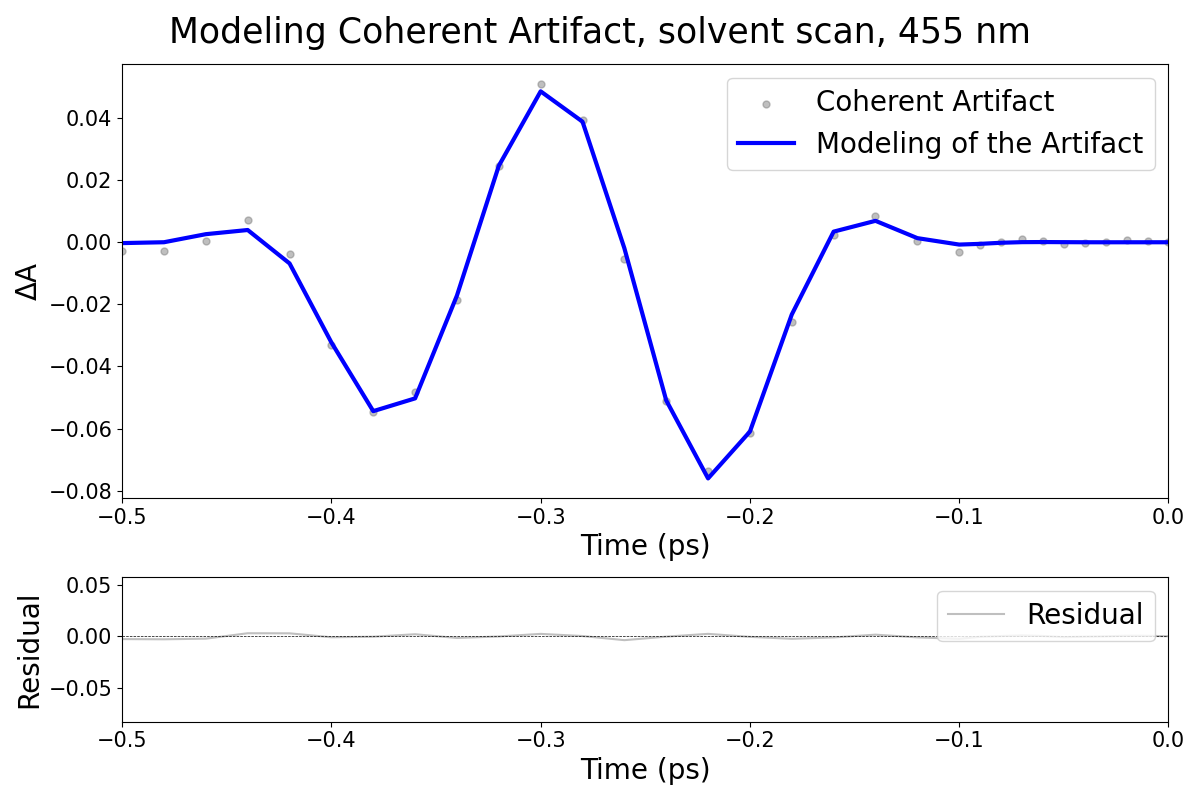

In [80]:
wv_1 = 455 #in nm

xml_region = dataset_solvent.data
single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time= single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])

# Set up lmfit parameters
params = lmfit.Parameters()
params.add('B', value=  234.685734 , min = 0,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi', value=99   ,vary = True) #phase shift of the modulation 
params.add('A0', value=  -0.06680426     , vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1', value=0, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM', value= 0.1,min=0, vary = True) #FWHM 
params.add('CA_center', value=  -0.29, vary = True) #Center of the chirp 



minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
result_init = minimizer.minimize()

x_lims = [max_time-0.2,max_time+0.3]
fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, Fcos(result_init.params, time), color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims) 


residuals = data - Fcos(result_init.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv_1} nm",fontsize=25)
plt.tight_layout()



# Print the fit report
print(lmfit.fit_report(result_init))

## Fit the full region 

Text(0.5, 1.0, 'Fit')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

Text(0.5, 1.0, 'Solvent Scan')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

Text(0.5, 1.0, 'Difference')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

(0.0, 1.0, 0.0, 1.0)

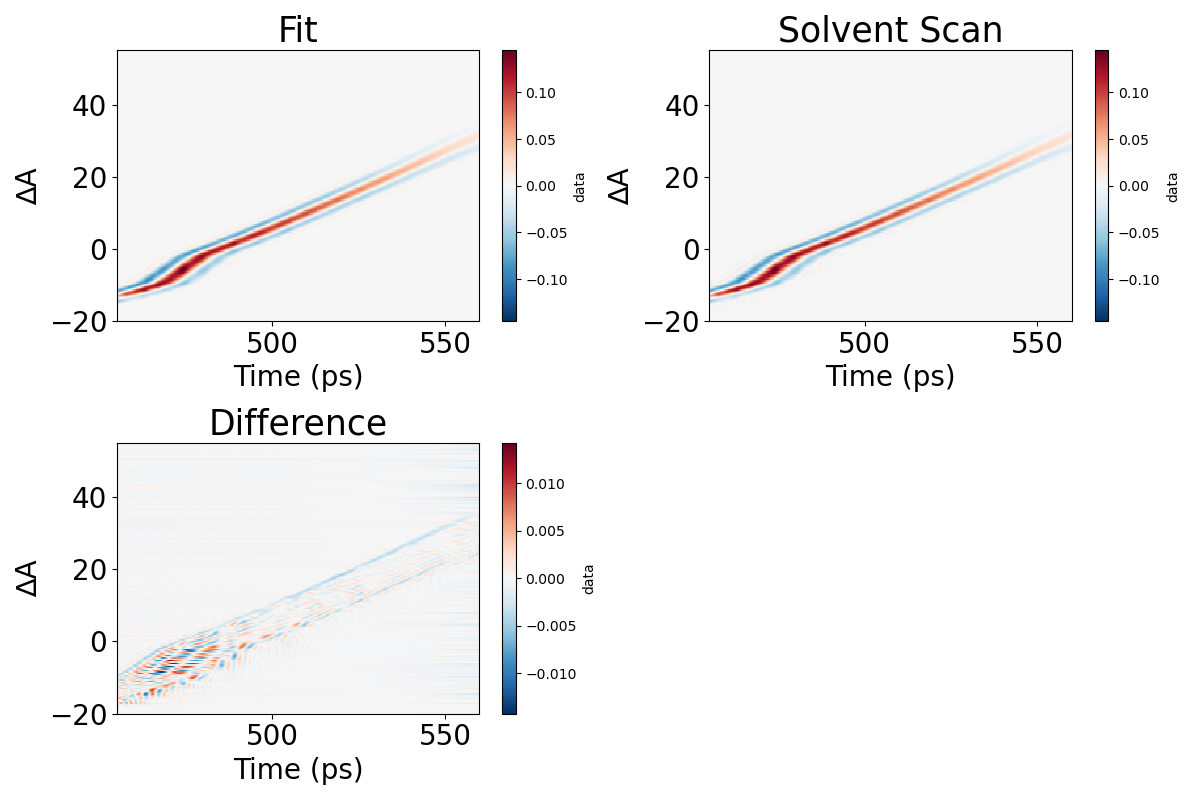

0.06759601671632497


In [120]:
wv_last = 560
xml_region = dataset_solvent.data.sel(spectral=slice(wv_1, wv_last))

fit_CA_param = {}
fit_CA_result = np.transpose(np.zeros_like(xml_region))

for i, wavelength in enumerate(xml_region.spectral):
    single_trace = xml_region.sel(spectral=[wavelength], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.reshape(np.shape(single_trace.data)[0])

    if i == 0:
        # Set up lmfit parameters for the first wavelength

        params = lmfit.Parameters()
        params.add('B', value= result_init.params['B'].value , min = 0,vary = False) #determines how quickly the fringe periodicity increases 
        params.add('Phi', value=result_init.params['Phi'].value  ,vary = False) #phase shift of the modulation 
        params.add('A0', value=  result_init.params['A0'].value     , vary = False) #Amplitude main Gaussian. Positve results in main peak down 
        params.add('A1', value=result_init.params['A1'].value, vary = False) # help fit of asymmetric artifacts 
        params.add('CA_FWHM', value= result_init.params['CA_FWHM'].value,min=0, vary = False) #FWHM 
        params.add('CA_center', value= result_init.params['CA_center'].value, vary = False) #Center of the chirp 
    else:
        # Use the previous wavelength's fitted parameters as initial values
        prev_wavelength = xml_region.spectral[i - 1].item()
        prev_params = fit_CA_param[prev_wavelength]
        params = lmfit.Parameters()
        for name, param in prev_params.items():
            params.add(name, value=param.value,vary=True) #, min=param.value*0.5, max=param.value*1.5

    # Perform minimization
    minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
    result = minimizer.minimize()

    # Store the fit result in the dictionary to be used for the next wavelength
    fit_CA_param[wavelength.item()] = result.params
    fit_CA_result[i] = Fcos(result.params, time)

dataset_fit_CA = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(fit_CA_result))
    },
    coords={
        "time": xml_region.time,
        "spectral": xml_region.spectral
    }
)

# Assuming dataset_fit and dataset_fit2 are already defined
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 1 row, 2 columns

# Plot the first dataset
dataset_fit_CA['data'].plot.imshow(ax=axes[0, 0])
axes[0, 0].set_title("Fit",fontsize=25)
axes[0, 0].set_aspect("auto")  # Set aspect ratio
axes[0, 0].set_xlabel("Time (ps)",fontsize=20)
axes[0, 0].set_ylabel("∆A",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=20)


# Plot the second dataset
xml_region.plot.imshow(ax=axes[0, 1])
axes[0, 1].set_title("Solvent Scan",fontsize=25)
axes[0, 1].set_aspect("auto")  # Set aspect ratio
axes[0, 1].set_xlabel("Time (ps)",fontsize=20)
axes[0, 1].set_ylabel("∆A",fontsize=20)
axes[0, 1].tick_params(axis='both', which='major', labelsize=20)

diff = xml_region - dataset_fit_CA
diff['data'].plot.imshow(ax=axes[1, 0])
axes[1, 0].set_title("Difference",fontsize=25)
axes[1, 0].set_aspect("auto")  # Set aspect ratio
axes[1, 0].set_xlabel("Time (ps)",fontsize=20)
axes[1, 0].set_ylabel("∆A",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=20)

# Hide the second subplot in the second row
axes[1, 1].axis('off')



plt.tight_layout()
plt.show();

Q1 = np.sqrt(np.mean((xml_region.data - dataset_fit_CA.data)**2)) / np.sqrt(np.mean((xml_region.data)**2))
print(Q1.values)


## visualize single CA fit

(0.0, 1.0)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(0.0, 1.0)

(-0.06850220747570011, 0.10623984559408096)

Text(0.5, 0.98, 'Modeling Coherent Artifact, solvent scan, 500 nm')

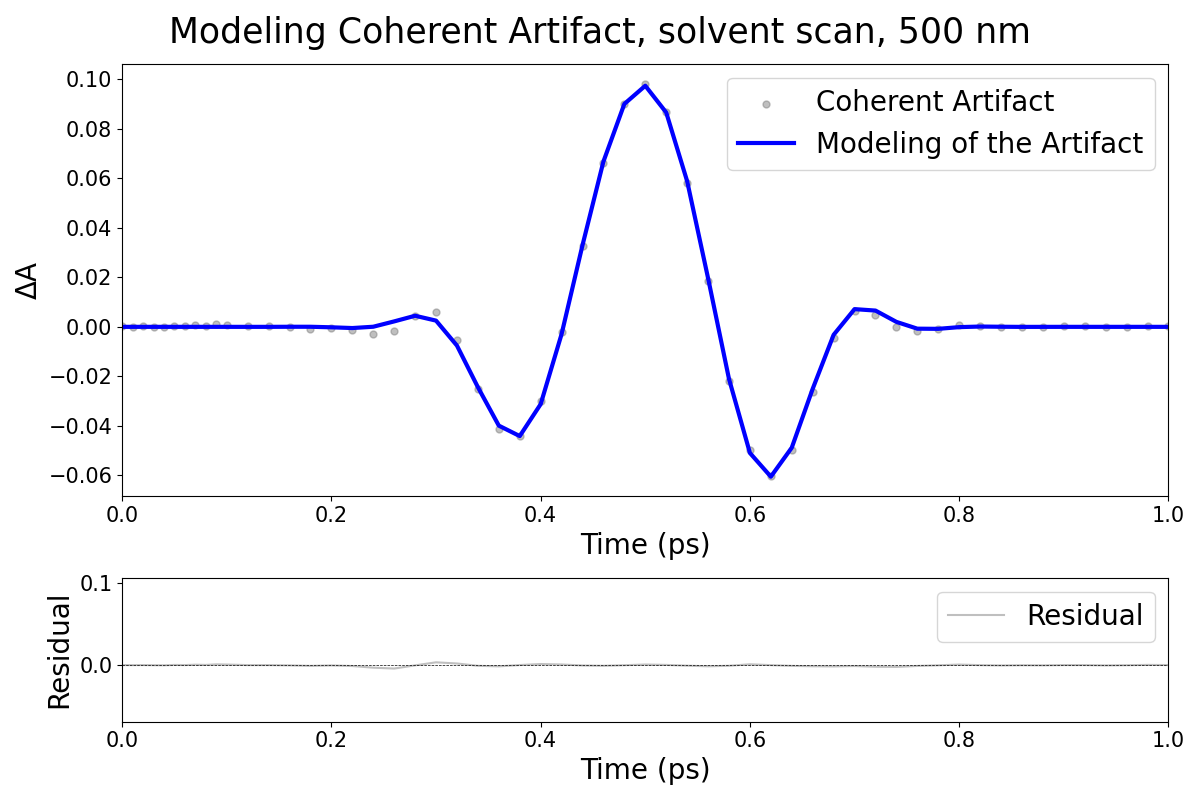

In [241]:
wv = 500 #in nm

single_trace = xml_region.sel(spectral = [wv], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])
x_lims = [max_time-0.5,max_time+0.5]

fit_fcos =  dataset_fit_CA['data'].sel(spectral = [wv], method = "nearest").sel(time = slice(max_time-0.5,max_time+0.5))
fit_fcos = fit_fcos.values.reshape(np.shape(single_trace.data)[0])

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, fit_fcos, color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - fit_fcos
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv} nm",fontsize=25)
plt.tight_layout()


# Import Scan

<xarray.Dataset> Size: 3MB
Dimensions:   (time: 189, spectral: 2048)
Coordinates:
  * time      (time) float64 2kB -15.0 -5.0 -1.0 -0.9 -0.8 ... 7.0 8.0 9.0 10.0
  * spectral  (spectral) float64 16kB 312.3 312.5 312.7 ... 782.4 782.6 782.8
Data variables:
    data      (time, spectral) float64 3MB 0.0003735 -0.0008585 ... 0.0005459


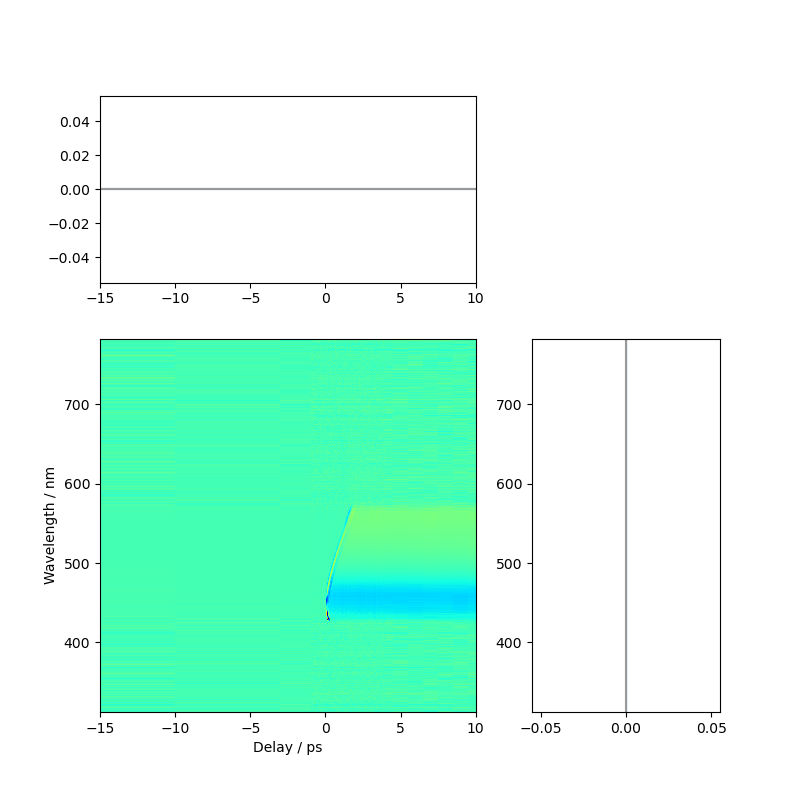

In [5]:
time_file = askopenfilename(filetypes=[("Text files", "*.txt")], title="Select Time vector data")
time = np.loadtxt(time_file)
time = time / 1000  # convert from fs to ps

# Get TA scan files
ta_scan_files = askopenfilenames(filetypes=[("Text files", "*.txt")], title="Select solvent scan file(s)")

if len(ta_scan_files) > 1:
    Full_Data = np.zeros((2048, len(time), len(ta_scan_files))) #Array that will contain all the 
    for n, file in enumerate(ta_scan_files):
        data = np.loadtxt(file)
        Full_Data[:, :, n] = data  # save data array to 3D array (lambda, time, scan)
    
    scan = np.mean(Full_Data, axis=2)
    scan = scan- np.mean(scan[:,1:3],axis=1)[:, np.newaxis] #Baseline correction 
else:
    scan = np.loadtxt(ta_scan_files[0])
# Now 'scan' contains the processed data

#Create an xarray to manipulate the data (much easier)
dataset = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(scan))
    },
    coords={
        "time": time,
        "spectral": lambda_values
    }
)

# Print the dataset
print(dataset)

heatmap_interactive(dataset.time, dataset.spectral, dataset['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

# Check degradation

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Max intensity')

Text(0.5, 0, 'scan number')

<function matplotlib.pyplot.show(block=None)>

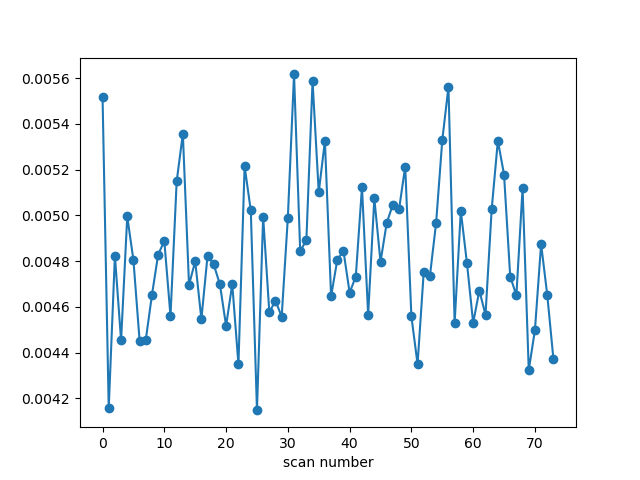

In [6]:
# Check the degradation over time
wl = 540
intensity = np.zeros(Full_Data.shape[2])
idx_wl = (np.abs(lambda_values - wl)).argmin()
time_search = (np.abs(time - 3)).argmin() #look after 3ps to avoid coherent artifact

for i in range(Full_Data.shape[2]):
    intensity[i] = np.max(np.abs(Full_Data[idx_wl,time_search:,i]))

plt.figure()
plt.plot(intensity, marker = 'o')
plt.xlabel('Max intensity')
plt.xlabel('scan number')
plt.show
    



<Figure size 640x480 with 0 Axes>

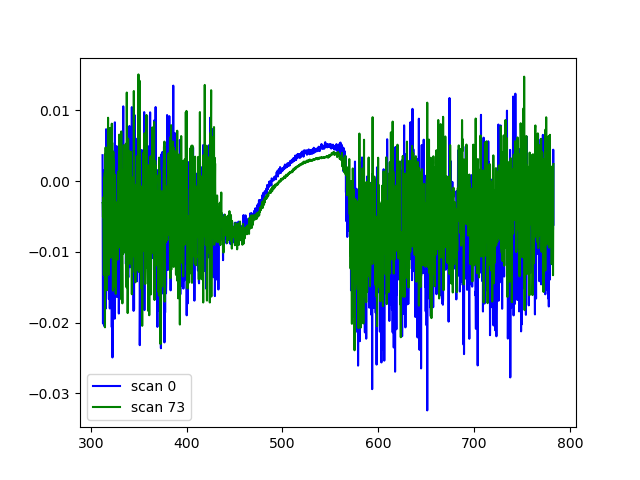

In [8]:
last = Full_Data.shape[2]-1
time_search = (np.abs(time - 15)).argmin() #look after 3ps to avoid coherent artifact
plt.figure()
plt.plot(lambda_values,Full_Data[:,time_search,0],'b',label = 'scan 0')
plt.plot(lambda_values,Full_Data[:,time_search,last],'g',label = f'scan {last}')
#plt.plot(lambda_values,Full_Data[:,time_search,40],'r',label = 'scan 40')
plt.legend()
plt.show()

# Check difference with CA 

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (ps)')

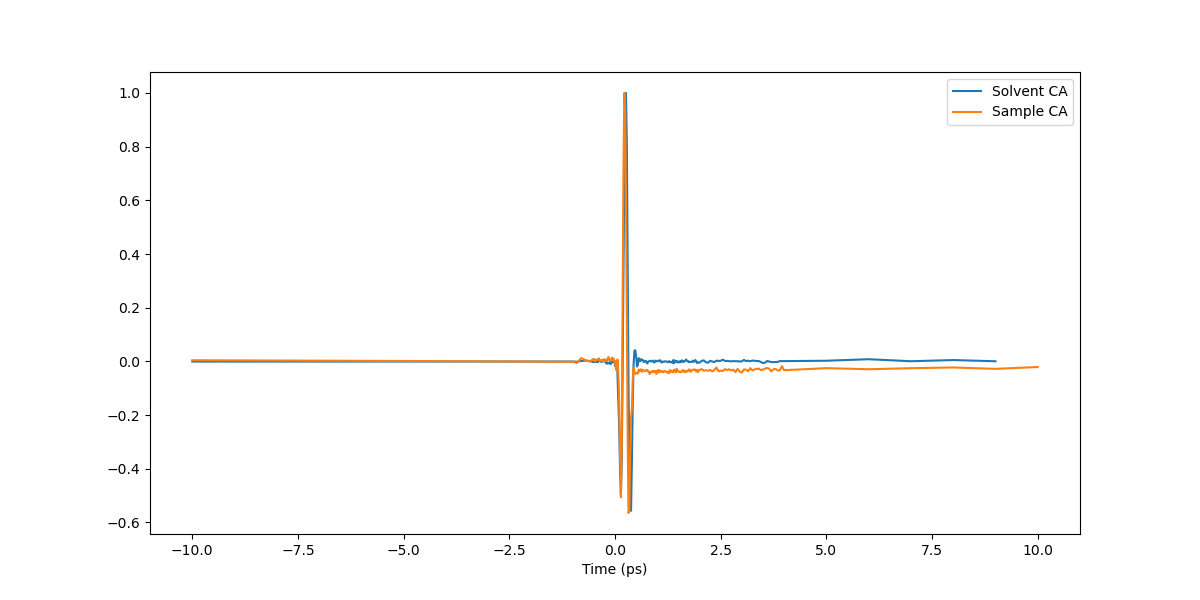

In [45]:
wv = 480
CA = dataset_solvent.data.sel(spectral = [wv], method="nearest")
shifted_time = CA.time - 0.04 # Shift time
shifted_CA = CA.assign_coords(time=shifted_time)
dt = dataset.data.sel(spectral = [wv], method="nearest")

# Normalize both
dt_norm = dt / dt.max()
CA_norm = shifted_CA / shifted_CA.max()

# Interpolate solvent CA onto the sample time grid
CA_interp = CA_norm.interp(time=dt.time)

# Now difference at matched time points
diff = dt_norm - CA_interp

plt.figure(figsize=(12,6))
plt.plot(CA_interp.time, CA_interp, label="Solvent CA")
plt.plot(dt.time, dt_norm, label="Sample CA")
#plt.plot(dt.time, diff, label="Difference")
plt.xlabel("Time (ps)")
plt.legend()
plt.show()

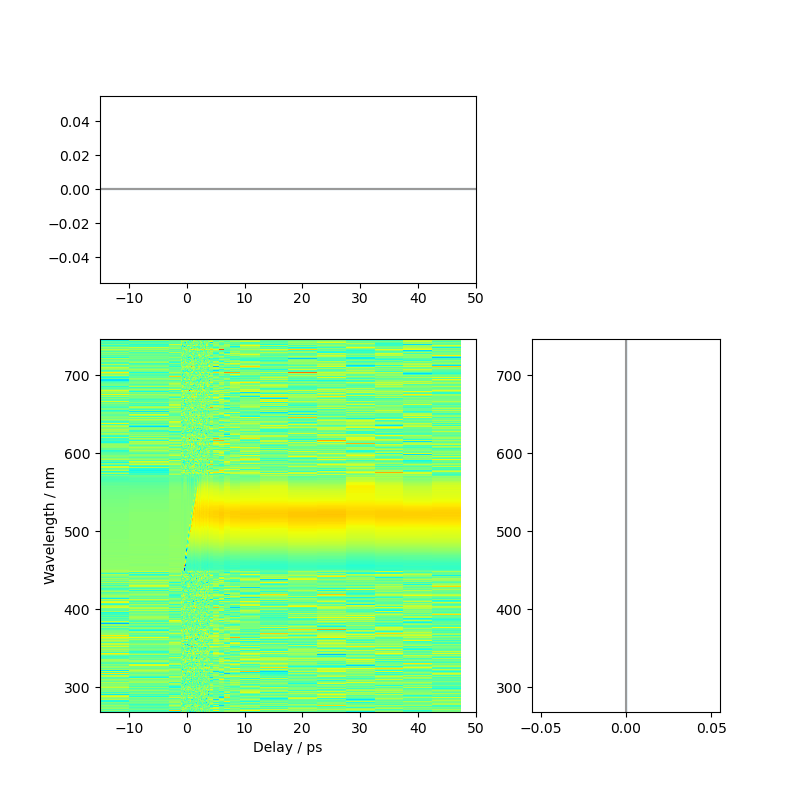

In [235]:
CA_free  = np.zeros_like(dataset_solvent.data)
for i,wv in enumerate(dataset.spectral):
    CA = dataset_solvent.data.sel(spectral = [wv], method="nearest")
    shifted_time = CA.time - 0.016# Shift time
    shifted_CA = CA.assign_coords(time=shifted_time)
    dt = dataset.data.sel(spectral = [wv], method="nearest")

    # Normalize both
    dt_norm = dt 
    CA_norm = shifted_CA * dt.max() / shifted_CA.max()

    # Interpolate solvent CA onto the sample time grid
    CA_interp = CA_norm.interp(time=dt.time)

    # Now difference at matched time points
    diff = dt_norm - CA_interp
    CA_free[:,i] = diff.squeeze()

dataset_NoCA = xr.Dataset(
    {
        "data": (["time","spectral",],CA_free)
    },
    coords={
        "time": dataset_solvent.time,
        "spectral": dataset_solvent.spectral
    }
)
heatmap_interactive(dataset_NoCA.time, dataset_NoCA.spectral, dataset_NoCA['data'].transpose('spectral','time'),'Difference plot',_symlog=False)

## Remove CA 

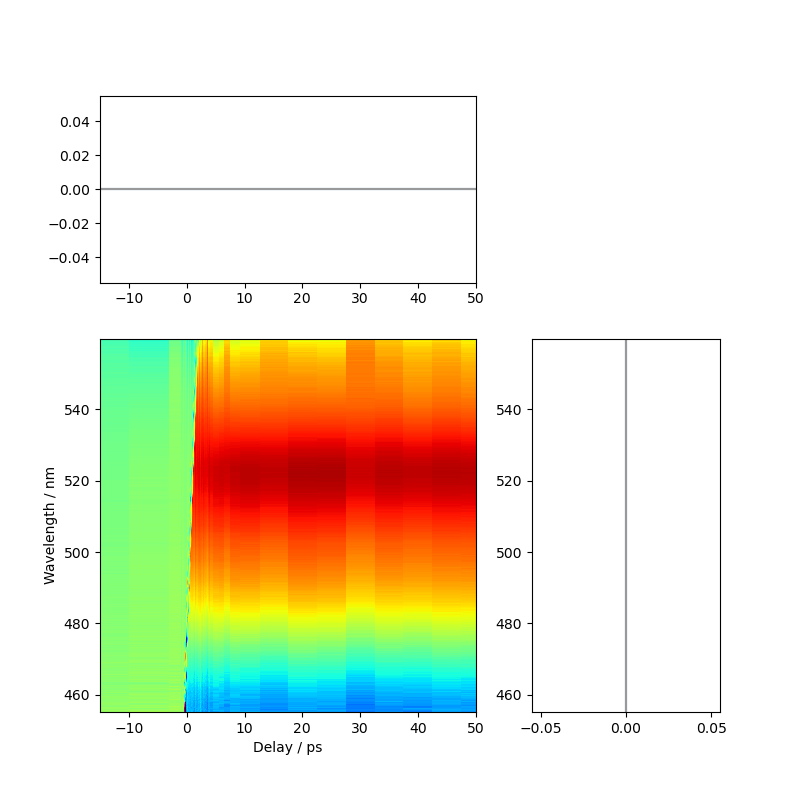

In [236]:
scan_region= dataset.data.sel(spectral=slice(wv_1, wv_last))
scan_CA_free = np.zeros((len(scan_region.spectral), len(scan_region.time)))
fit = np.zeros((len(scan_region.spectral), len(scan_region.time)))
for i, wv in enumerate(scan_region.spectral):
    single_trace = scan_region.sel(spectral = [wv], method="nearest") 
    time = single_trace.time.values
    data = single_trace.values.flatten()  # Normalize the data
    wv_fit = xml_region.spectral.sel(spectral = [wv], method="nearest").item()
    CA_norm_factor =  dataset_fit_CA.sel(spectral = [wv_fit], method = "nearest").max().data.item()/np.max(single_trace.values)
    center = fit_CA_param[wv_fit]['CA_center'].value - 0.016
    #the A coef does need to be scaled
    params = lmfit.Parameters()



    params.add('B', value= fit_CA_param[wv_fit]['B'].value,min= fit_CA_param[wv_fit]['B'].value*0.5,max= fit_CA_param[wv_fit]['B'].value*1.5, vary = True) #determines how quickly the fringe periodicity increases 
    params.add('Phi',value= fit_CA_param[wv_fit]['Phi'].value,min= fit_CA_param[wv_fit]['Phi'].value*0.75,max= fit_CA_param[wv_fit]['Phi'].value*1.5,vary = False) #phase shift of the modulation 
    params.add('A0', value=fit_CA_param[wv_fit]['A0'].value , min= fit_CA_param[wv_fit]['A0'].value *0.75,max= fit_CA_param[wv_fit]['A0'].value *1.5,vary = False) #Amplitude main Gaussian. Positve results in main peak down 
    params.add('A1',value= fit_CA_param[wv_fit]['A1'].value,min= fit_CA_param[wv_fit]['A1'].value*0.75,max= fit_CA_param[wv_fit]['A1'].value*1.5, vary = False) # help fit of asymmetric artifacts 
    params.add('CA_FWHM',value= fit_CA_param[wv_fit]['CA_FWHM'].value,min= fit_CA_param[wv_fit]['CA_FWHM'].value*0.75,max= fit_CA_param[wv_fit]['CA_FWHM'].value*1.5 ,vary = True) # FWHM
    params.add('CA_center',value= center ,min=center*0.95,max= center*1.15,vary = True)  #Center of the chirp  
    params.add('c',value=CA_norm_factor,min=CA_norm_factor*0.25,max= CA_norm_factor*1.75,vary = False)  #normalization factor shirp

    minimizer = lmfit.Minimizer(residuals_Fcos_complex, params, fcn_args=(time, data))
    result_initial = minimizer.minimize()
    residuals = data - Fcos_complex(result_initial.params, time)
    fit[i,:] = Fcos_complex(result_initial.params, time)
    scan_CA_free[i,:] = residuals


#Create an xarray to manipulate the data (much easier)
#Create an xarray to manipulate the data (much easier)
dataset_noCA = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(scan_CA_free))
    },
    coords={
        "time": scan_region.time.values,
        "spectral": scan_region.spectral.values
    }
)


#Create an xarray to manipulate the data (much easier)
dataset_fit = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(fit))
    },
    coords={
        "time": scan_region.time.values,
        "spectral": scan_region.spectral.values
    }
)


heatmap_interactive(dataset_noCA.time, dataset_noCA.spectral, dataset_noCA['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

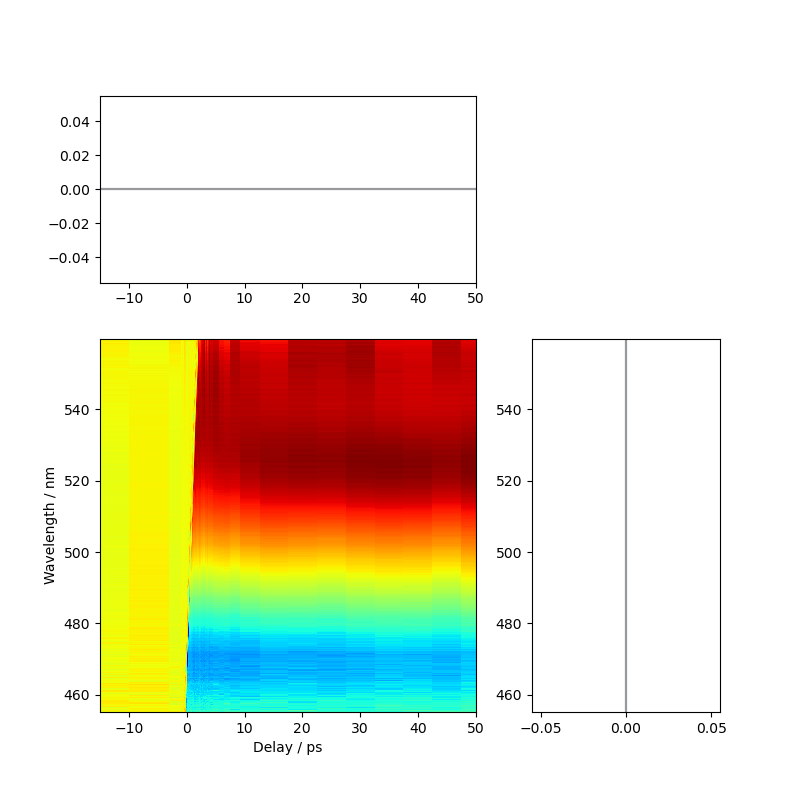

In [243]:


heatmap_interactive(dataset.time, dataset.spectral, dataset['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

In [245]:
dataset

<xarray.Dataset> Size: 709kB
Dimensions:   (spectral: 449, time: 196)
Coordinates:
  * time      (time) float64 2kB -15.0 -5.0 -1.0 -0.9 ... 35.0 40.0 45.0 50.0
  * spectral  (spectral) float64 4kB 455.2 455.4 455.6 ... 559.4 559.6 559.8
Data variables:
    data      (spectral, time) float64 704kB -0.00017 -4e-05 ... 0.0045 0.00404

<Figure size 1000x600 with 0 Axes>

(-0.25, 3.0)

Text(0.5, 0, 'time [ps]')

Text(0, 0.5, 'Wavelength [nm]')

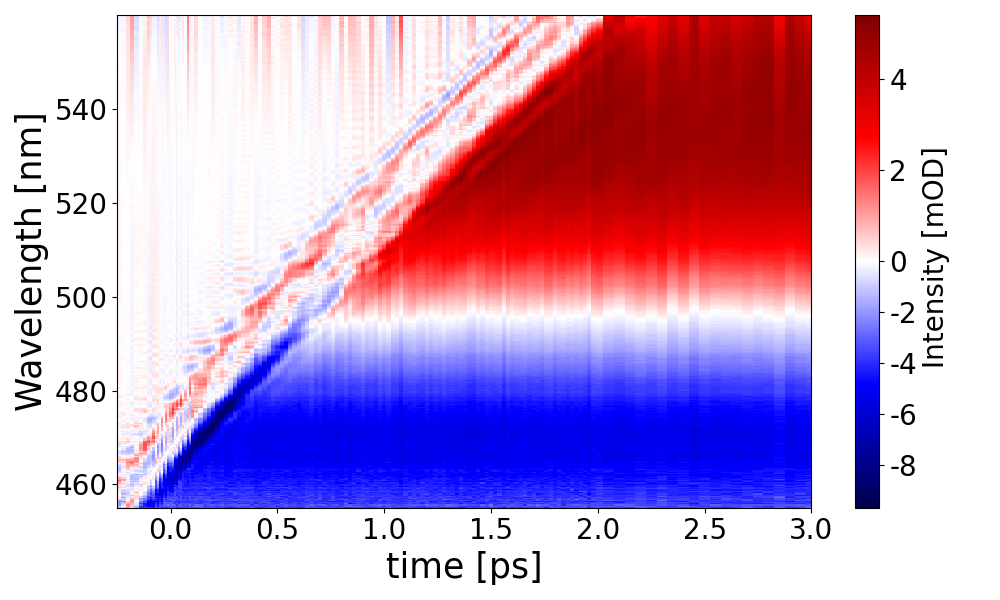

In [250]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

plt.figure(figsize=(10, 6))

scaled = dataset.data

# Use xarray's built-in plot for 2D heatmap
#vmin = -10e-3
vmin = scaled.min().item()
#vmax = 6e-3
vmax = scaled.max().item()

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

p = scaled.plot(
    x='time', y='spectral',
    cmap='seismic',  # or viridis, plasma, etc.
    norm=norm,
)



# Increase tick font size
p.colorbar.set_label( 'Intensity (OD)', fontsize=25)
p.axes.tick_params(labelsize=20)

# Optional: set axis titles if needed
p.axes.set_xlim(-0.25, 3)  # Only positive values allowed for log scale
p.axes.set_xlabel("time [ps]", fontsize=25)
p.axes.set_ylabel("Wavelength [nm]", fontsize=25)
#p.axes.set_title("Lifetime Map, fontsize=16)
# Scale colorbar ticks ×10³
def sci_formatter(x, pos):
    return f'{x*1e3:.0f}'  # or use scientific notation: f'{x*1e3:.0e}'

p.colorbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(sci_formatter))
p.colorbar.ax.tick_params(labelsize=20)  # Increase font size of ticks
p.colorbar.set_label(' Intensity [mOD]', fontsize=20)

plt.tight_layout()
plt.show()


## Single  visualization

(-0.020000000000000018, 0.98)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(-0.020000000000000018, 0.98)

(-0.02323275214523768, 0.03696112223619298)

Text(0.5, 0.98, 'Modeling Coherent Artifact, solvent scan, 500 nm')

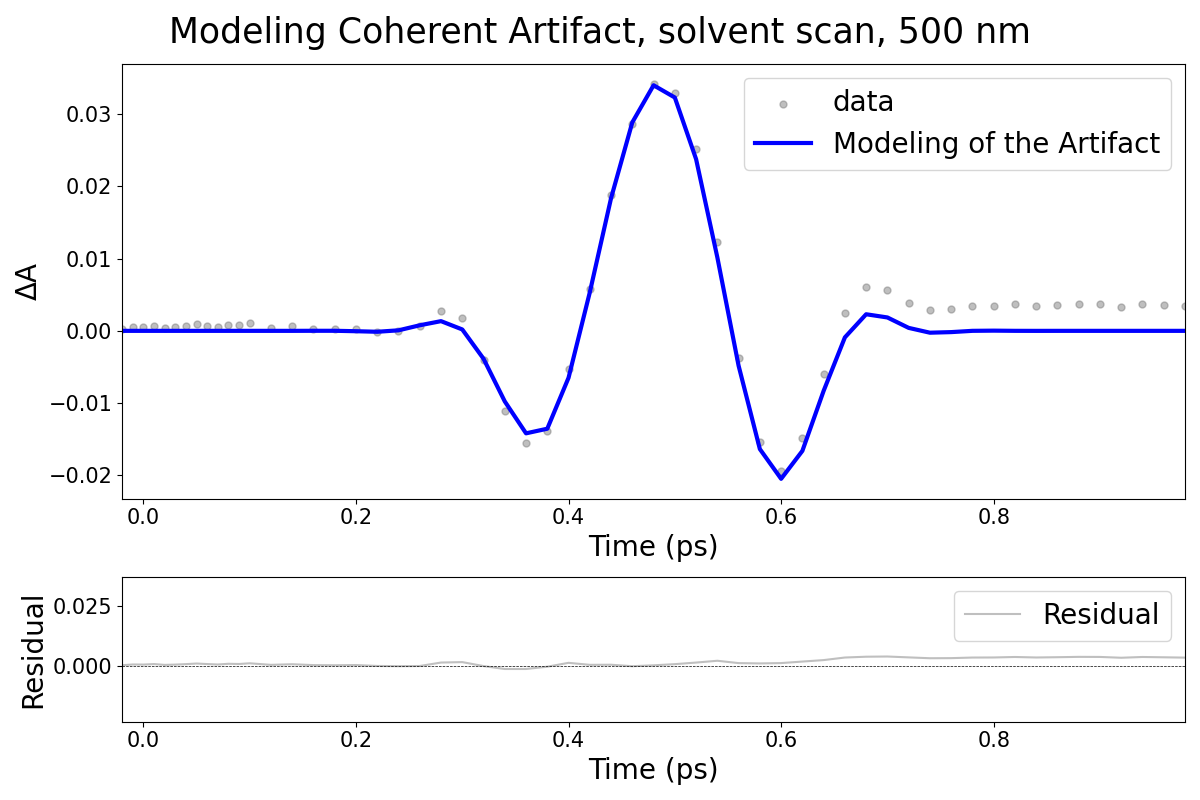

In [240]:
wv = 500 #in nm

single_trace = scan_region.sel(spectral = [wv], method="nearest") 
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])   # Normalize the data
x_lims = [max_time-0.5,max_time+0.5]

fit_fcos =  dataset_fit['data'].sel(spectral = [wv], method = "nearest").sel(time = slice(max_time-0.5,max_time+0.5))
fit_fcos = fit_fcos.values.reshape(np.shape(single_trace.data)[0])

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='data', alpha=0.5)
ax.plot(time, fit_fcos, color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = dataset_noCA['data'].sel(spectral = [wv], method = "nearest").sel(time = slice(max_time-0.5,max_time+0.5))
ax2.plot(residuals.time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv} nm",fontsize=25)
plt.tight_layout()

# Export

In [237]:
# Define the filename
filename = 'Cu(F-dchtmp)2__scan_forIRF_rep2.ana'

# Open the file for writing
with open(filename, 'w') as f:
    # Write the header
    f.write("%FILENAME={}\n".format(filename))
    f.write("%DATATYPE=TAVIS\n")
    f.write("%NUMBERSCANS=1\n")
    f.write("%TIMESCALE=ps\n")

    # Write the time list
    f.write("%TIMELIST={}\n".format(" ".join(f"{value:.2f}" for value in scan_region.time.values)))
    
    # Write the wavelength list
    f.write("%WAVELENGTHLIST={}\n".format(" ".join(f"{value:.2f}" for value in scan_region.spectral.values)))
    
    # Write the intensity matrix
    intensity_matrix = scan_region.data  # Get the intensity values
    i = 0
    for row in intensity_matrix:
        if i == 0:
            f.write("%INTENSITYMATRIX=\n {}\n".format(" ".join(f"{value:.5f}" for value in row)))
            i = i+1
        else:
            f.write("{}\n".format(" ".join(f"{value:.5f}" for value in row)))

print(f"File '{filename}' has been created successfully.")

46

16

15

14

1037

...

3668

3670

3664

3666

File 'Cu(F-dchtmp)2__scan_forIRF_rep2.ana' has been created successfully.


In [238]:
# Define the filename
filename = 'Cu(F-dchtmp)2_CA_fit_substracted_rep2.ana'

# Open the file for writing
with open(filename, 'w') as f:
    # Write the header
    f.write("%FILENAME={}\n".format(filename))
    f.write("%DATATYPE=TAVIS\n")
    f.write("%NUMBERSCANS=1\n")
    f.write("%TIMESCALE=ps\n")

    # Write the time list
    f.write("%TIMELIST={}\n".format(" ".join(f"{value:.2f}" for value in dataset_noCA.time.values)))
    
    # Write the wavelength list
    f.write("%WAVELENGTHLIST={}\n".format(" ".join(f"{value:.2f}" for value in dataset_noCA.spectral.values)))
    
    # Write the intensity matrix
    intensity_matrix = dataset_noCA.data.values  # Get the intensity values
    i = 0
    for row in intensity_matrix:
        if i == 0:
            f.write("%INTENSITYMATRIX=\n {}\n".format(" ".join(f"{value:.5f}" for value in row)))
            i = i+1
        else:
            f.write("{}\n".format(" ".join(f"{value:.5f}" for value in row)))

print(f"File '{filename}' has been created successfully.")

52

16

15

14

1037

...

3668

3670

3664

3666

File 'Cu(F-dchtmp)2_CA_fit_substracted_rep2.ana' has been created successfully.


# Import old scan if needed

In [242]:
import numpy as np
import xarray as xr

filename = '/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu_August25/analysis/Cu(dmp)2/Cu(dmp)2_CA_fit_substracted.ana'

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

# Storage
time = None
wavelengths = None
matrix_lines = []
matrix_flag = False

# Parse
for line in lines:
    line = line.strip()
    if line.startswith("%TIMELIST="):
        time = np.array([float(v) for v in line.split("=")[1].split()])
    elif line.startswith("%WAVELENGTHLIST="):
        wavelengths = np.array([float(v) for v in line.split("=")[1].split()])
    elif line.startswith("%INTENSITYMATRIX="):
        matrix_flag = True
        # This line might already have numbers after "="
        parts = line.split("=")
        if len(parts) > 1 and parts[1].strip():
            matrix_lines.append(parts[1].strip())
    elif matrix_flag:
        if line:  # skip empty lines
            matrix_lines.append(line)

# Convert matrix
matrix = np.array([[float(v) for v in row.split()] for row in matrix_lines])

# Ensure correct orientation (depends on how you wrote it)
# From your write loop: you wrote "for row in intensity_matrix"
# so row = wavelength, col = time
# Shape should be (len(wavelengths), len(time))
print("matrix shape:", matrix.shape)
print("expected:", len(wavelengths), len(time))

# Build xarray Dataset
dataset = xr.Dataset(
    {
        "data": (["spectral", "time"], np.transpose(matrix))
    },
    coords={
        "time": time,
        "spectral": wavelengths
    }
)


matrix shape: (196, 449)
expected: 449 196
